In [1]:
from probjax.distributions.transformed_distribution import TransformedDistribution
from probjax.distributions import Normal
from probjax.distributions.independent import Independent
from probjax.core import inverse_and_logabsdet, inverse
from probjax.core.jaxpr_propagation.graph import JaxprGraph

import haiku as hk
from probjax.nn.coupling import CouplingMLP
from probjax.nn.helpers import Flip

import optax
from optax import adam

import jax
from jax import numpy as jnp

In [2]:
input_dim = 2

In [3]:
p = Independent(Normal(jnp.zeros(input_dim), jnp.ones(input_dim)), 1)

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [4]:
target_samples1 = p.sample(jax.random.PRNGKey(0), (1000,)) + 5.0
target_samples2 = p.sample(jax.random.PRNGKey(1), (1000,)) - 5.0
xs = jnp.concatenate([target_samples1, target_samples2], axis=0)


In [18]:

def affine_bijector(loc_and_scale, x):
    loc, scale = jnp.split(loc_and_scale, 2, axis=-1)
    scale = jax.nn.softplus(scale)
    return loc + scale*x

@hk.without_apply_rng
@hk.transform
def forward(x):
    nn = hk.Sequential([CouplingMLP(1, affine_bijector, input_dim),Flip(), CouplingMLP(1, affine_bijector, input_dim), Flip(), CouplingMLP(1, affine_bijector, input_dim)])
    return nn(x)

init, apply = forward.init, forward.apply

In [19]:
params = init(jax.random.PRNGKey(0), jnp.ones((1,input_dim)))
y = apply(params, jnp.ones((1,input_dim)))

q = TransformedDistribution(p, lambda x: apply(params, x))
samples = q.sample(jax.random.PRNGKey(0), (10,))

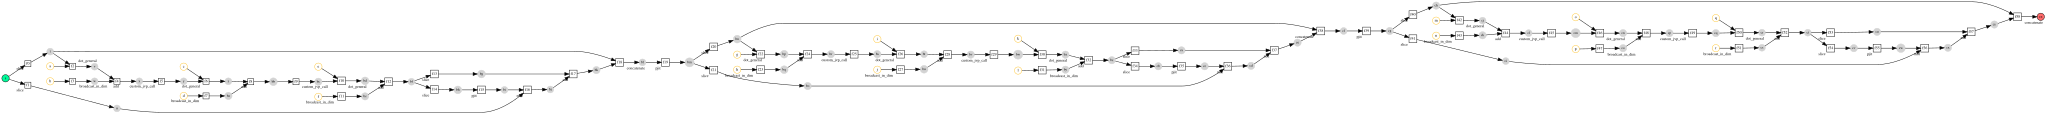

In [20]:
g = JaxprGraph(jax.make_jaxpr(lambda x: apply(params, x))(jnp.ones((1, input_dim))).jaxpr)
g

In [21]:
out = apply(params, samples)

In [22]:
jacobians = jax.vmap(jax.jacfwd(lambda x: apply(params, x)))(samples)
logabsdet = jnp.linalg.slogdet(jacobians)[1]

In [23]:
logabsdet

Array([-1.019, -1.243, -0.92 , -1.29 , -1.093, -1.351, -1.222, -1.078,
       -1.108, -0.937], dtype=float32)

In [24]:
inv_logdet_fn = jax.vmap(inverse_and_logabsdet(lambda x: apply(params, x)))
inv_samples, logdet = inv_logdet_fn(out)

In [25]:
logdet

Array([1.019, 1.243, 0.92 , 1.29 , 1.093, 1.351, 1.222, 1.078, 1.108,
       0.937], dtype=float32)

In [26]:
samples - inv_samples

Array([[ 0.,  0.],
       [ 0., -0.],
       [ 0.,  0.],
       [ 0.,  0.],
       [ 0.,  0.],
       [ 0., -0.],
       [ 0.,  0.],
       [-0., -0.],
       [ 0.,  0.],
       [-0.,  0.]], dtype=float32)

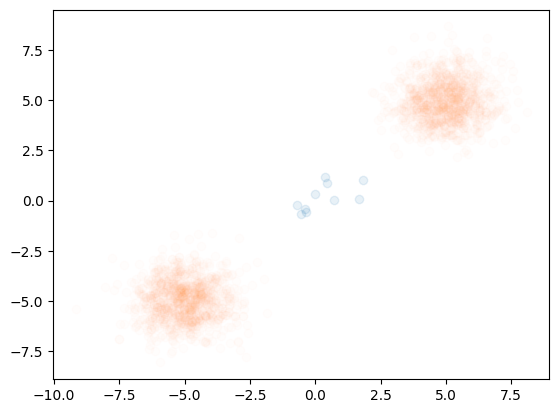

In [27]:
import matplotlib.pyplot as plt
plt.scatter(samples[:,0], samples[:,1], alpha=0.1)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.01)

In [28]:
@jax.jit
def loss_fn(params, x):
    q = TransformedDistribution(p, lambda x: apply(params, x))
    return -q.log_prob(x).mean()

In [32]:
optimizer = adam(1e-3)
opt_state = optimizer.init(params)

@jax.jit
def step(params, opt_state, x):
    loss, g = jax.value_and_grad(loss_fn)(params, x)
    updates, updated_state = optimizer.update(g, opt_state)
    new_params = optax.apply_updates(params, updates)

    return new_params, updated_state, loss

for i in range(5000):
    xs_batch = jax.random.choice(jax.random.PRNGKey(i), xs, (1000,))
    params, opt_state, loss = step(params, opt_state, xs_batch)
    if i % 100 == 0:
        print(loss)

4.164523
4.0814347
4.0418
4.0134025
3.9111695
3.9264288
3.8387733
3.8699539
3.8215094
3.8215325
3.790171
3.7903173
3.7973096
3.7770402
3.782628
3.758278
3.7110715
3.7524836
3.8046472
3.7843404
3.7919261
3.7151282
3.7319074
3.7356837
3.75471
3.754859
3.7405667
3.749819
3.7795327
3.7559445
3.7406409
3.740173
3.675948
3.7147677
3.6676397
3.768944
3.7701886
3.7203894
3.7360566
3.7355003
3.7328582
3.7486036
3.6850584
3.7466364
3.7367947
3.6629603
3.7359004
3.7207286
3.6766405
3.6623337


In [33]:
q = TransformedDistribution(p, lambda x: apply(params, x))
samples = q.sample(jax.random.PRNGKey(0), sample_shape=(1000,))

(-10.0, 10.0)

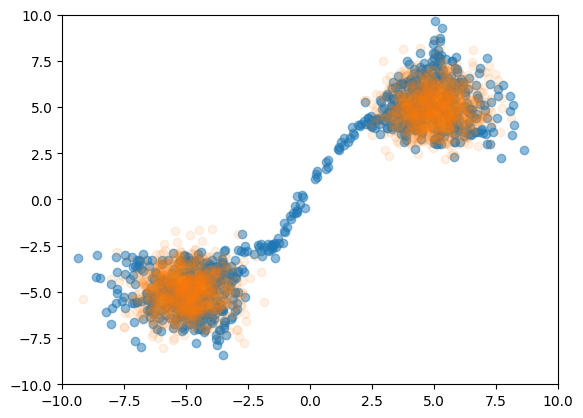

In [34]:
import matplotlib.pyplot as plt
plt.scatter(samples[:,0], samples[:,1], alpha=0.5)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.1)

plt.xlim(-10, 10)
plt.ylim(-10, 10)